    # SAM2 Parameter Sweep

    SAM 2 is box-prompted here, so the meaningful knobs are the ones that create the box:
    the raw RGB-difference threshold and the amount of dilation applied before the largest
    changed component is boxed.

    | Param | What it does |
    |---|---|
    | `diff_thresh` | Pixel-difference cutoff used to find changed regions before boxing. Lower = bigger candidate box. |
    | `dilate` | Binary dilation applied before boxing. Higher = box expands around the changed region. |
    


In [18]:
%matplotlib inline

import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (cwd, *cwd.parents):
    if (candidate / 'data').exists() and (candidate / 'change_detection_results').exists():
        PROJECT_ROOT = candidate.resolve()
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate the repo root from cwd={cwd}. "
        "Expected a parent directory containing both 'data' and 'change_detection_results'."
    )

CHANGE_DIR = PROJECT_ROOT / 'change_detection_results'
SWEEP_DIR = CHANGE_DIR / 'param_sweeps'
for path in (CHANGE_DIR, SWEEP_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device.upper()}')

Device: CUDA


In [19]:
from params import SAM2_BASELINE
from sweep_utils import load_dataset_pair, show_image_pair, show_sweep
from test_change_detection import sam2_mask

DATASET = 'new3'   # <- change dataset here

project_root, data_dir, original_img, edited_img, original_path, edited_path = load_dataset_pair(DATASET)
checkpoint_path = project_root / SAM2_BASELINE['checkpoint']
assert checkpoint_path.exists(), f'SAM2 checkpoint not found: {checkpoint_path}'

print(f'Dataset: {DATASET}')
print(f'Checkpoint: {checkpoint_path}')
print(SAM2_BASELINE)


Dataset: new3
Checkpoint: E:\1ARZAANWORK\UNI\year2\UE_depth\mask_models\weights\sam2.1_hiera_large.pt
{'checkpoint': 'mask_models/weights/sam2.1_hiera_large.pt', 'model_cfg': 'configs/sam2.1/sam2.1_hiera_l.yaml', 'diff_thresh': 15.0, 'dilate': 8}


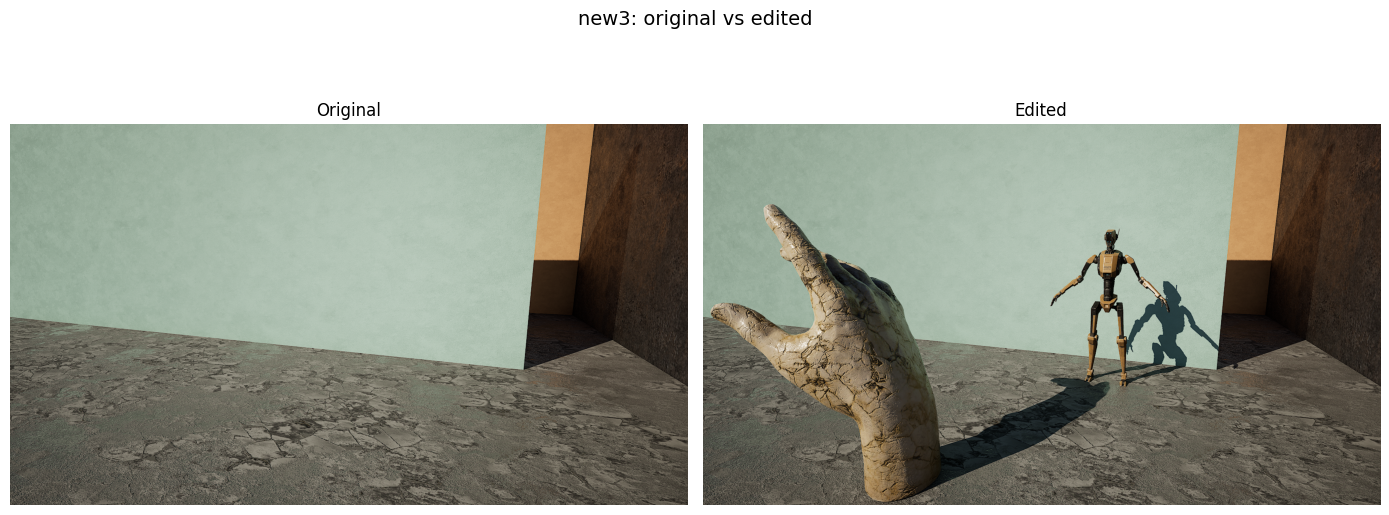

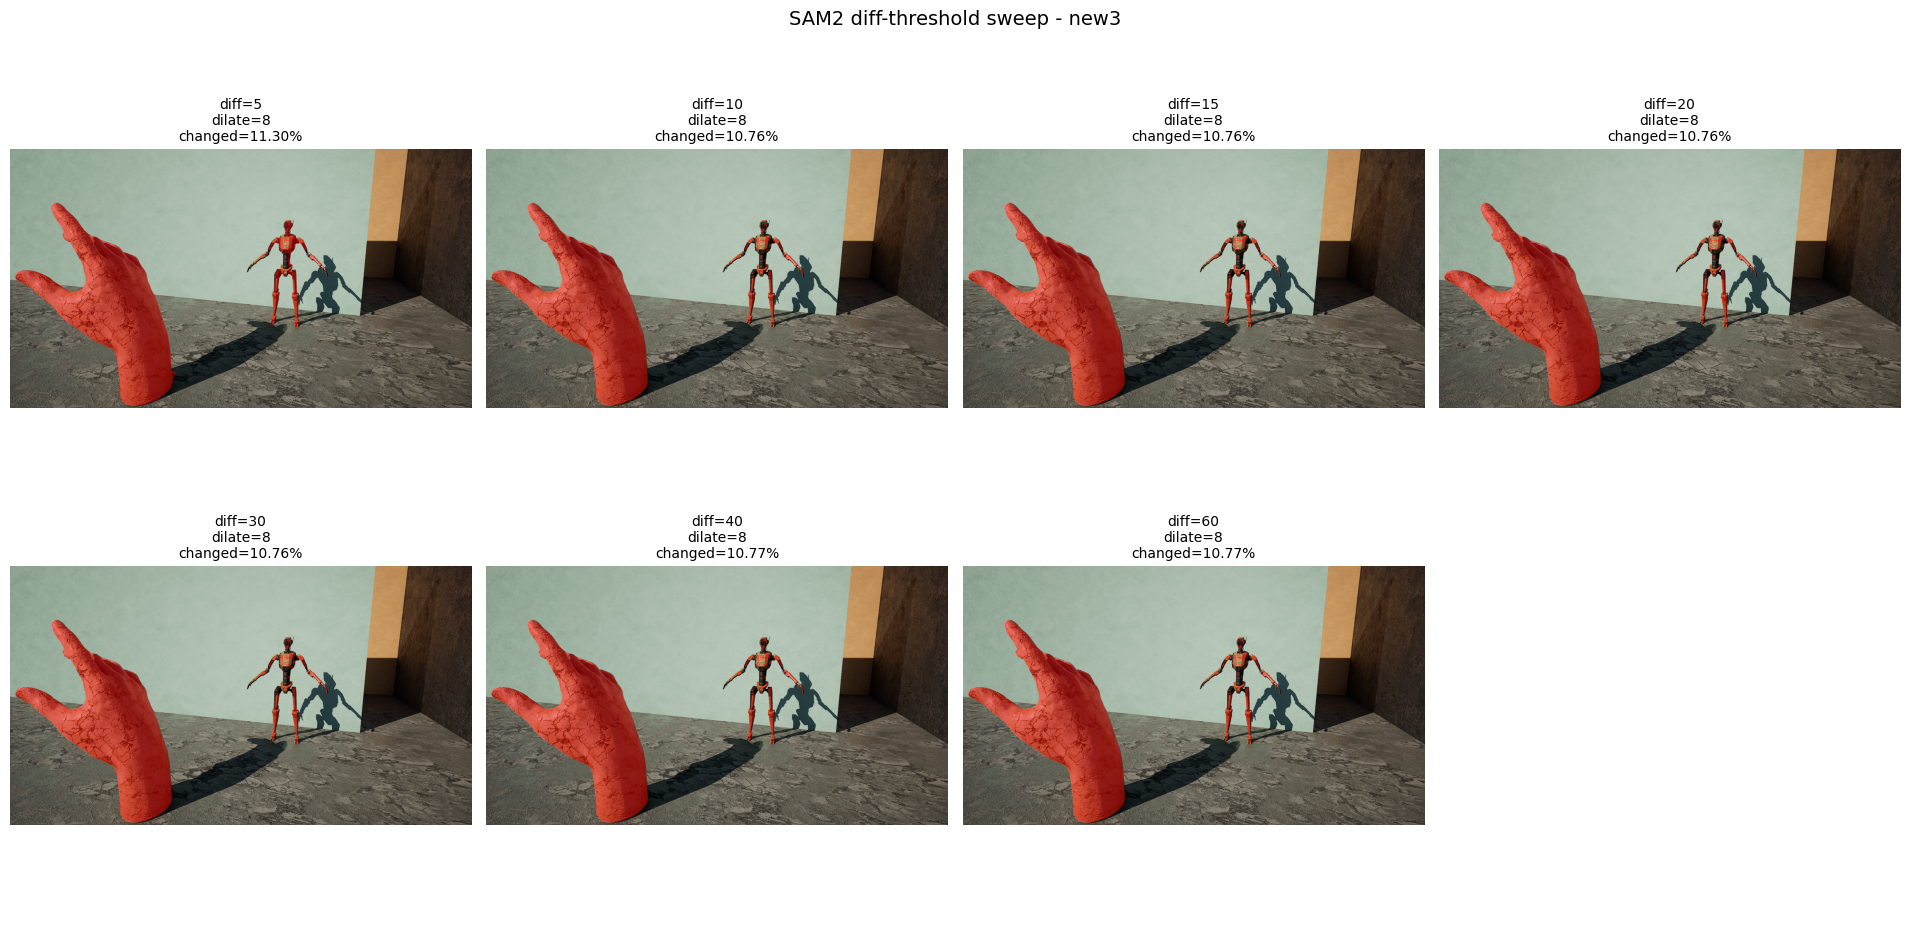

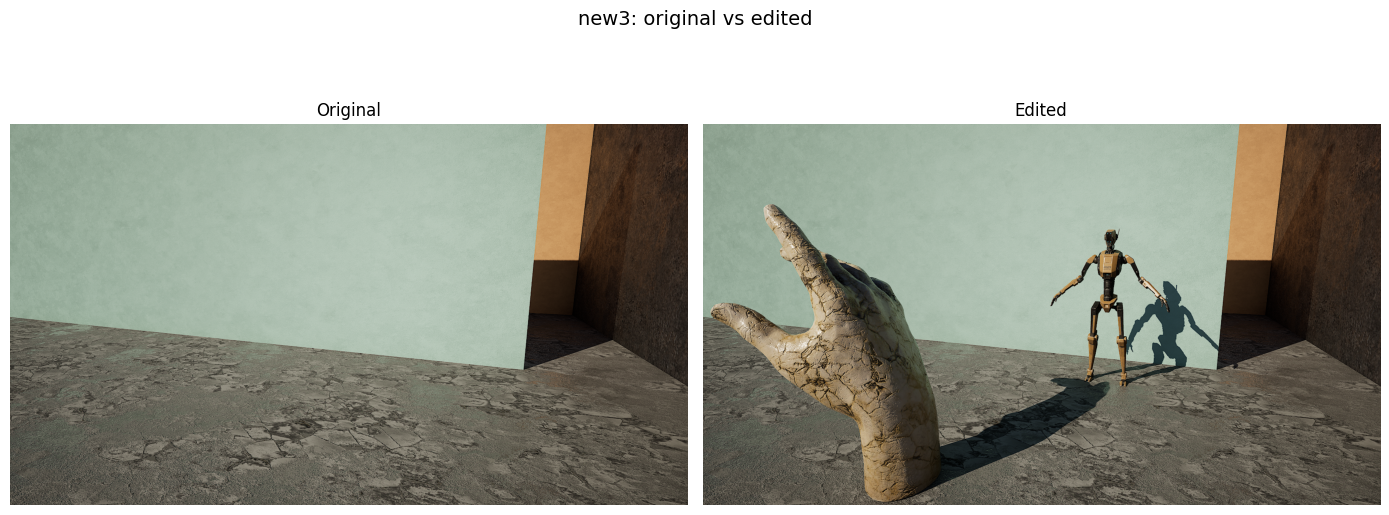

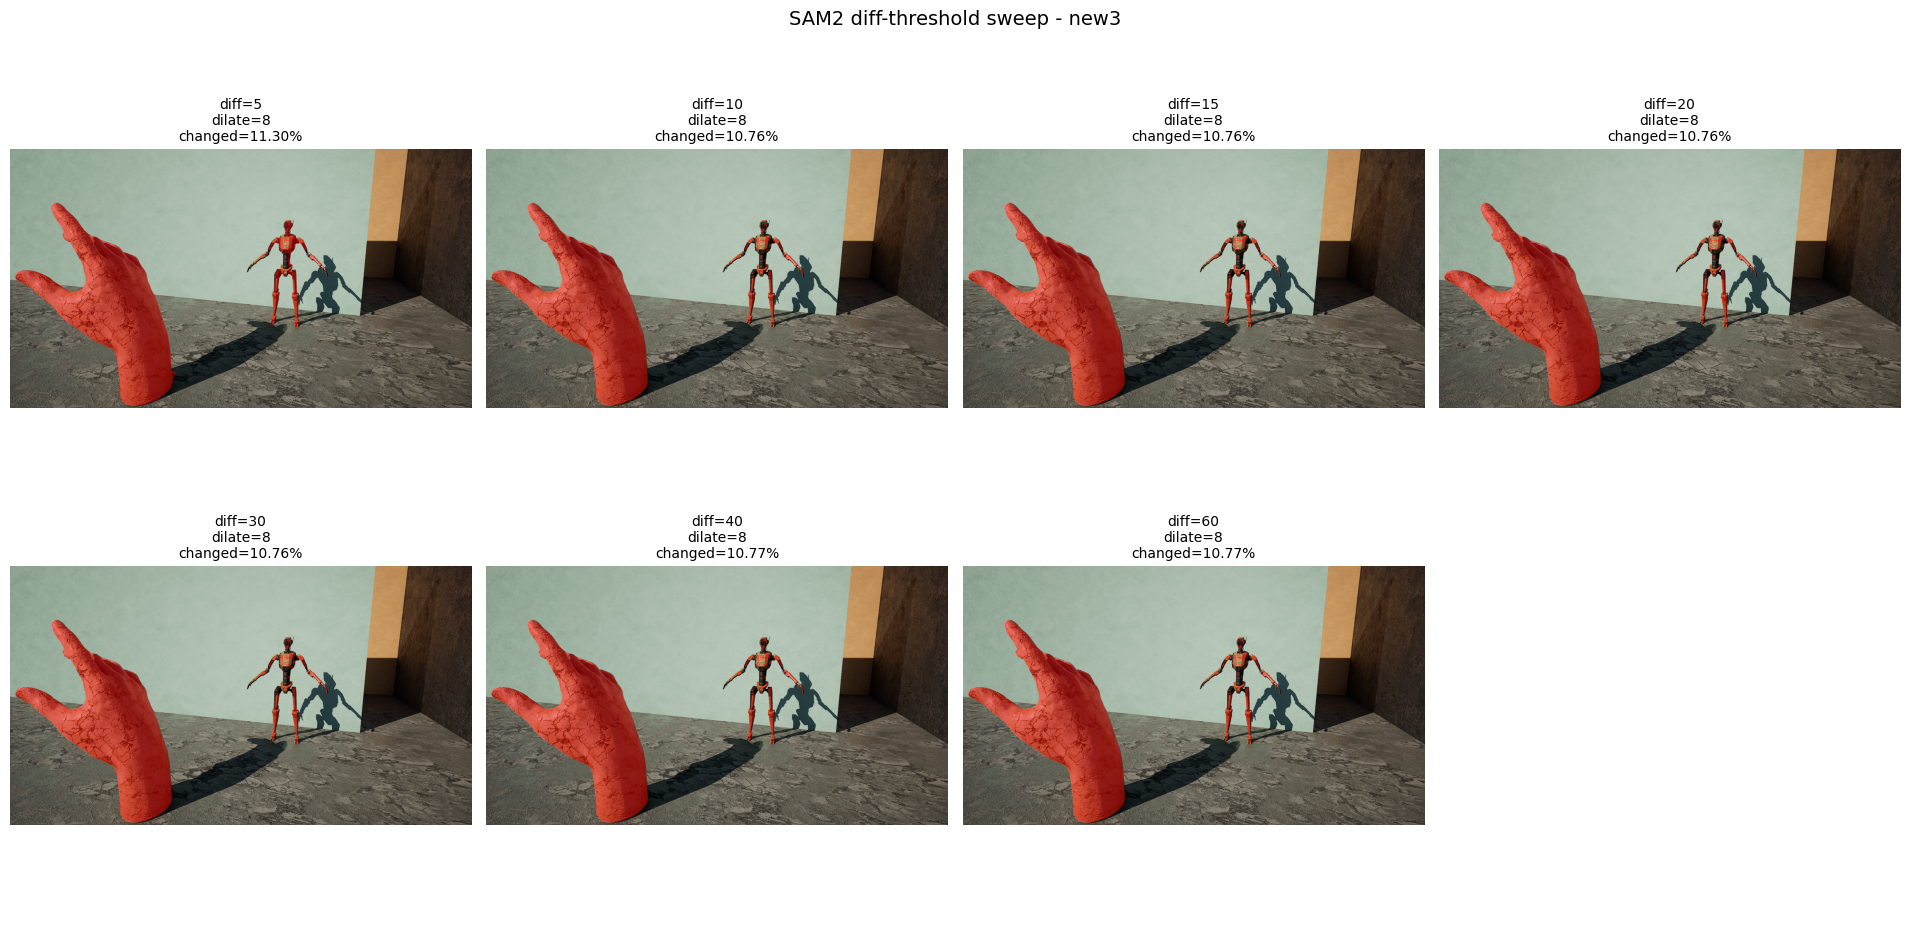

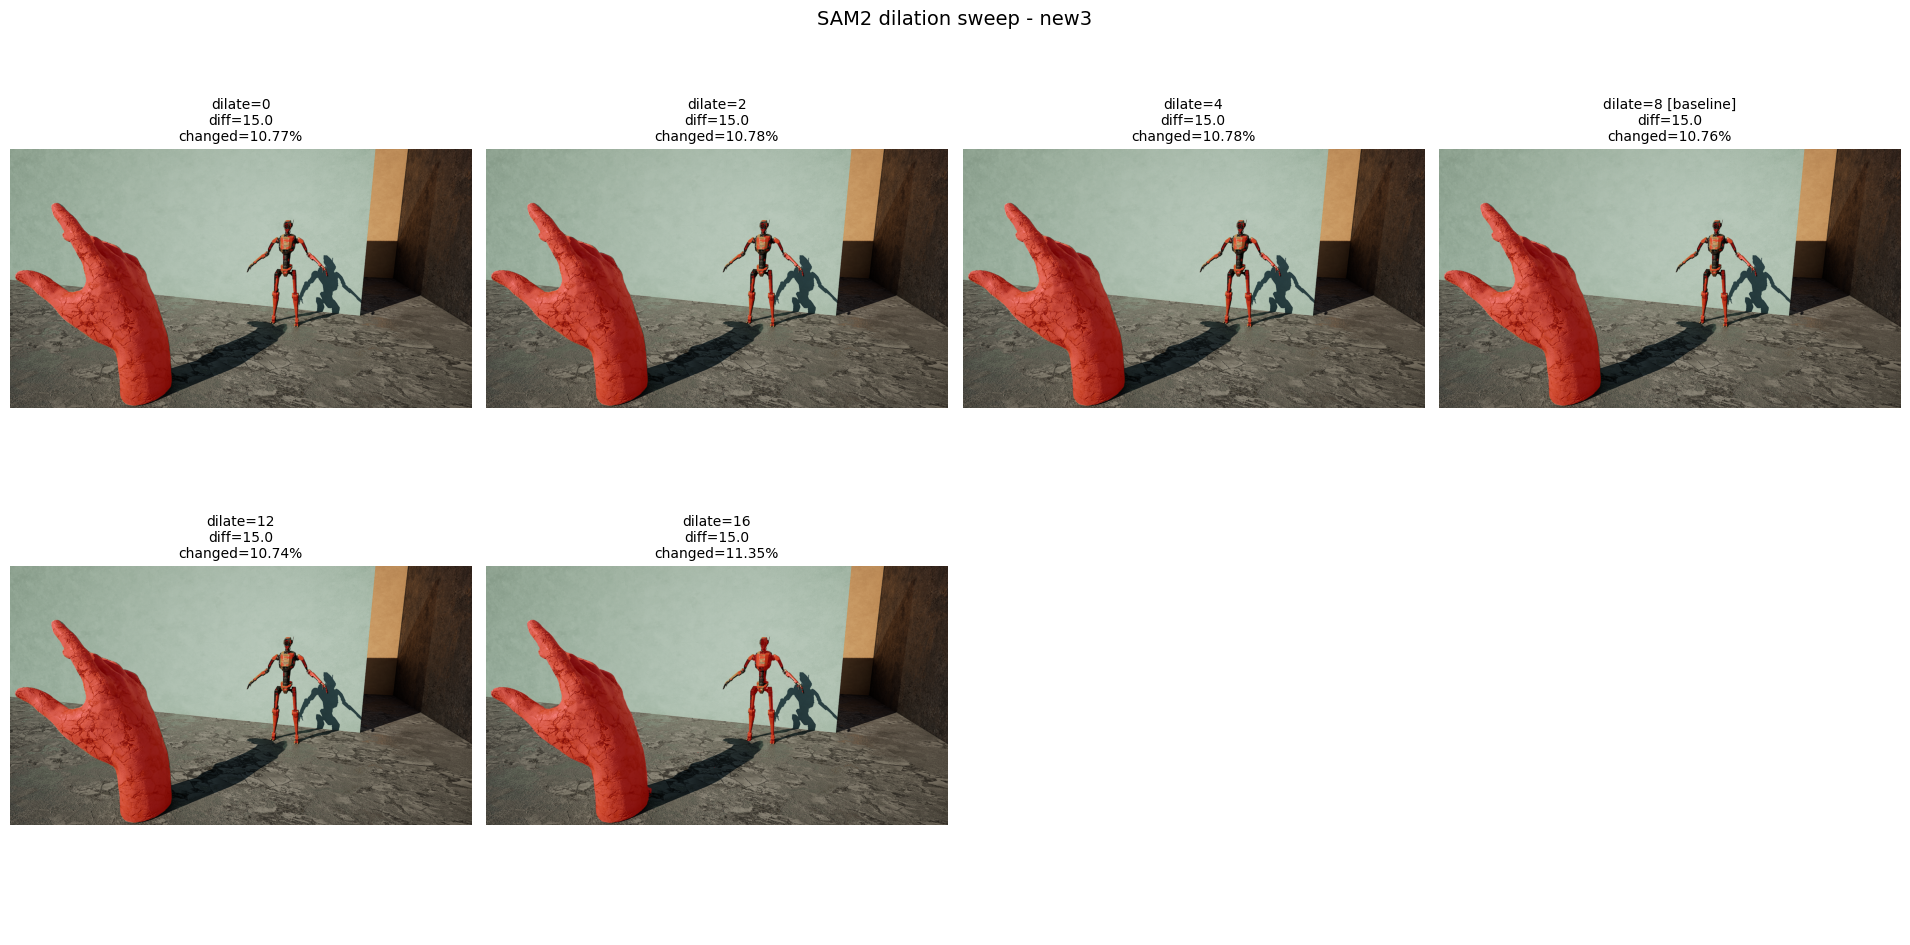

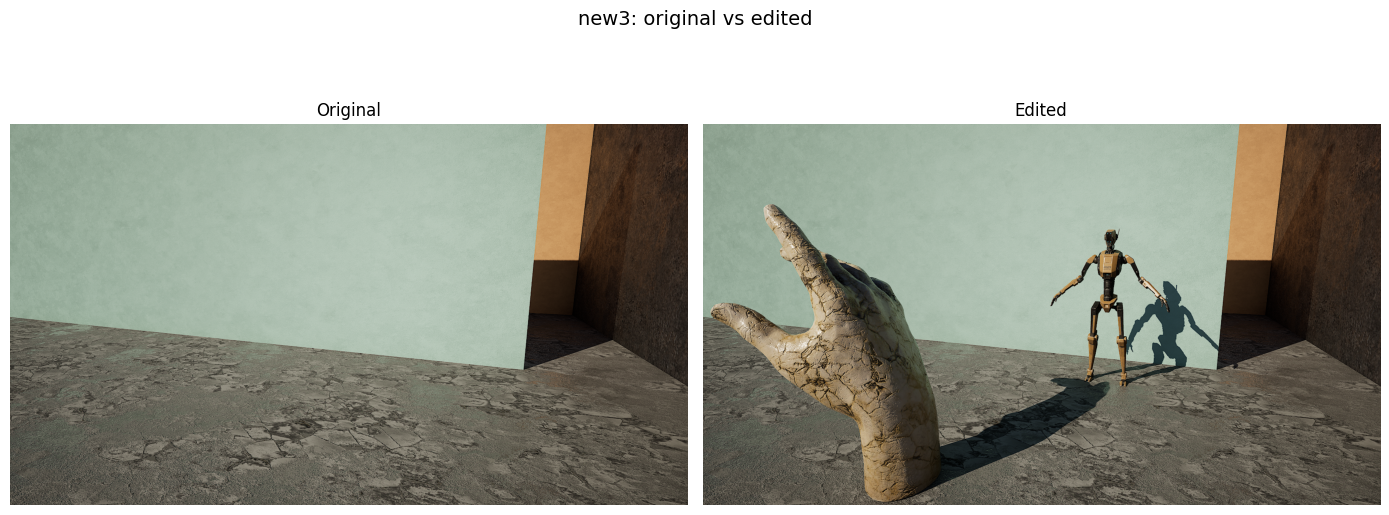

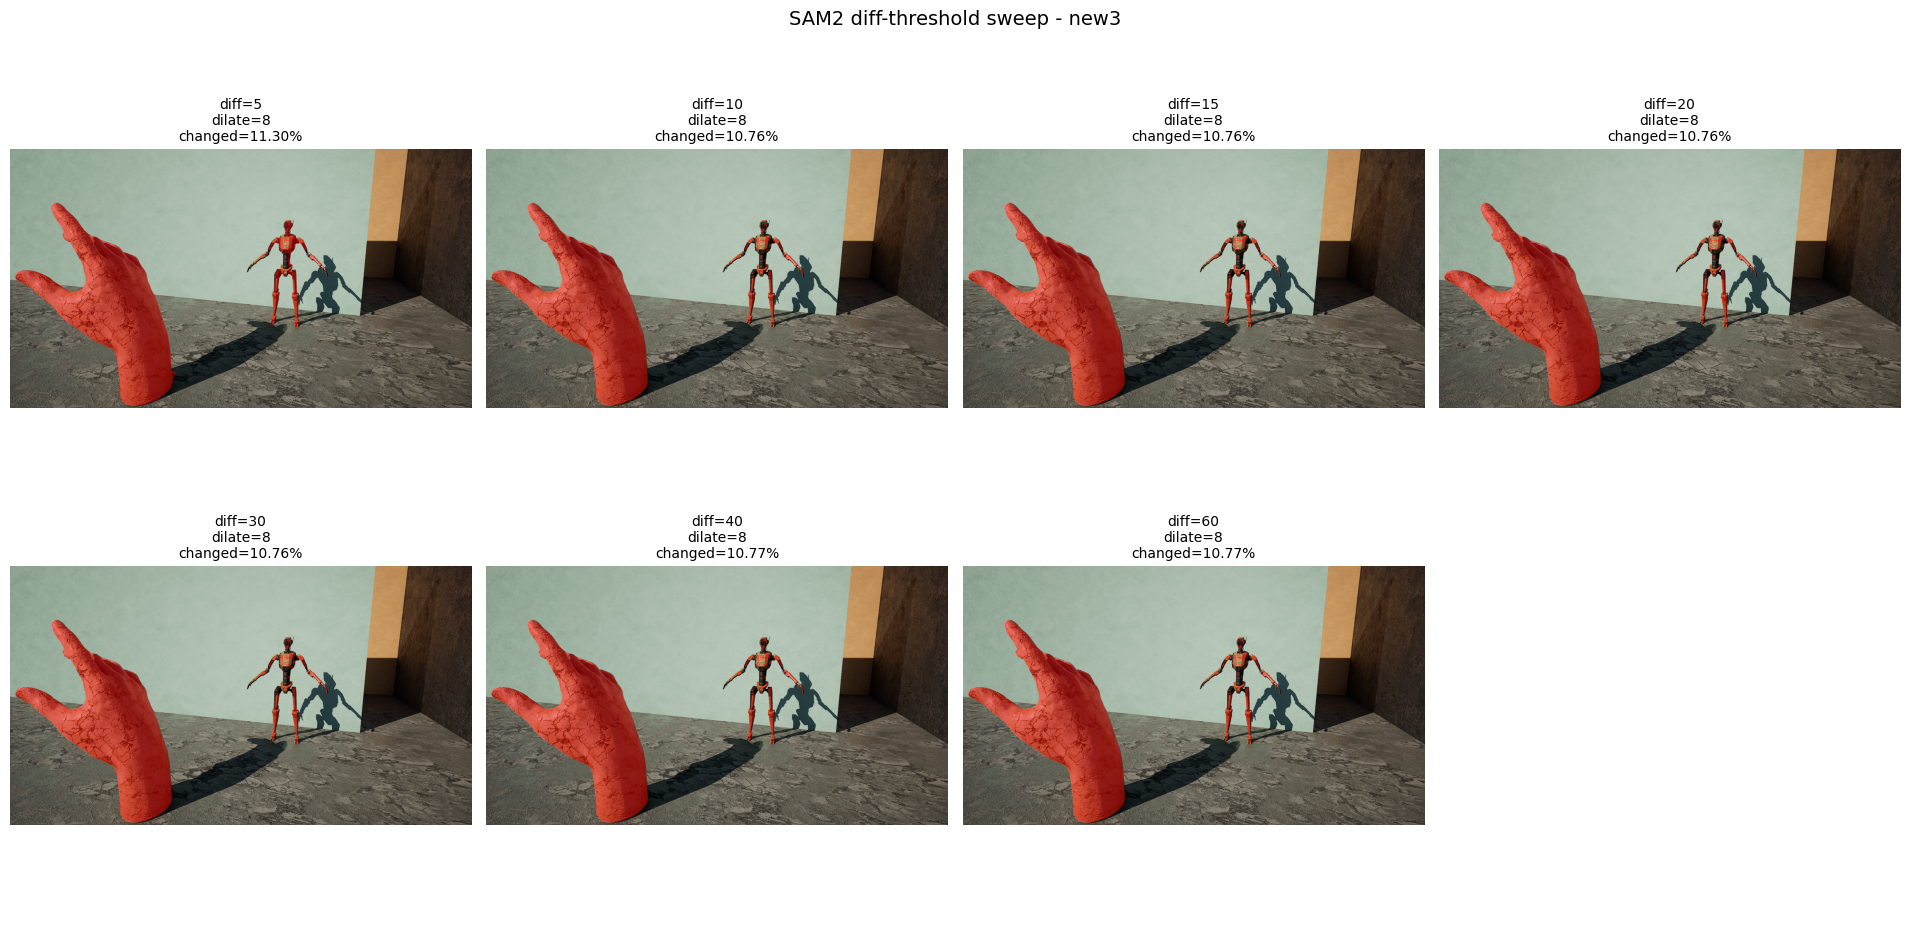

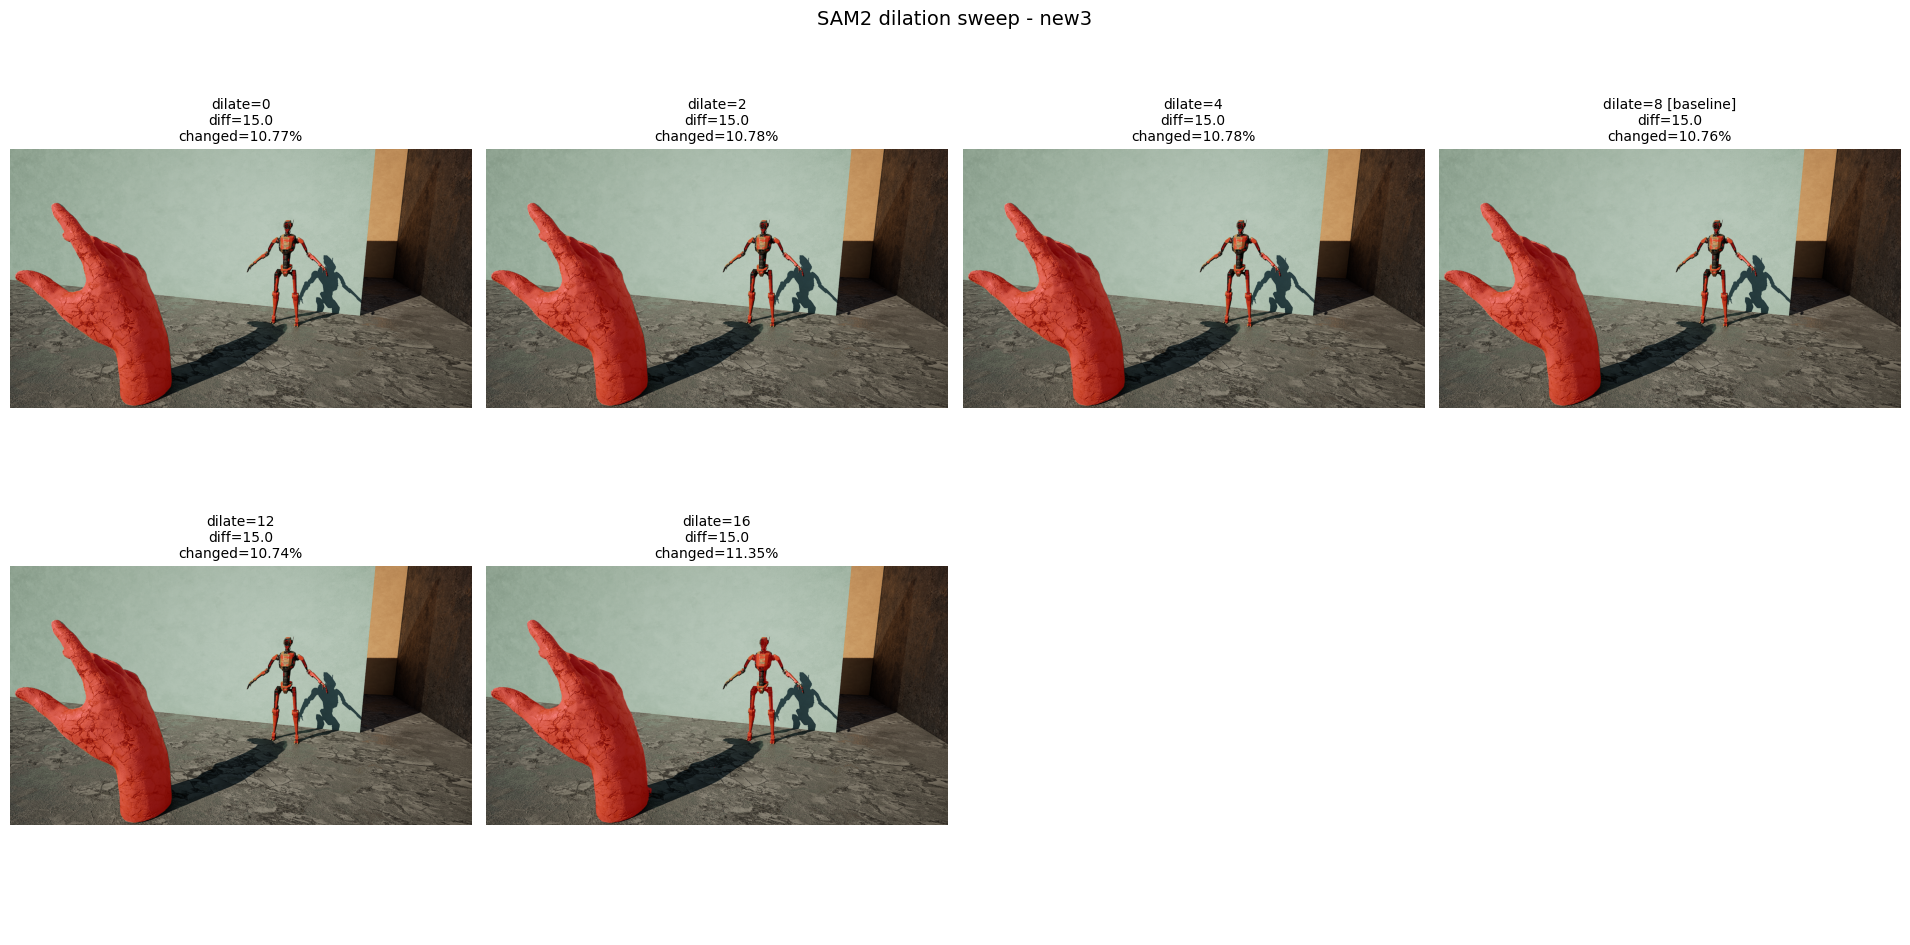

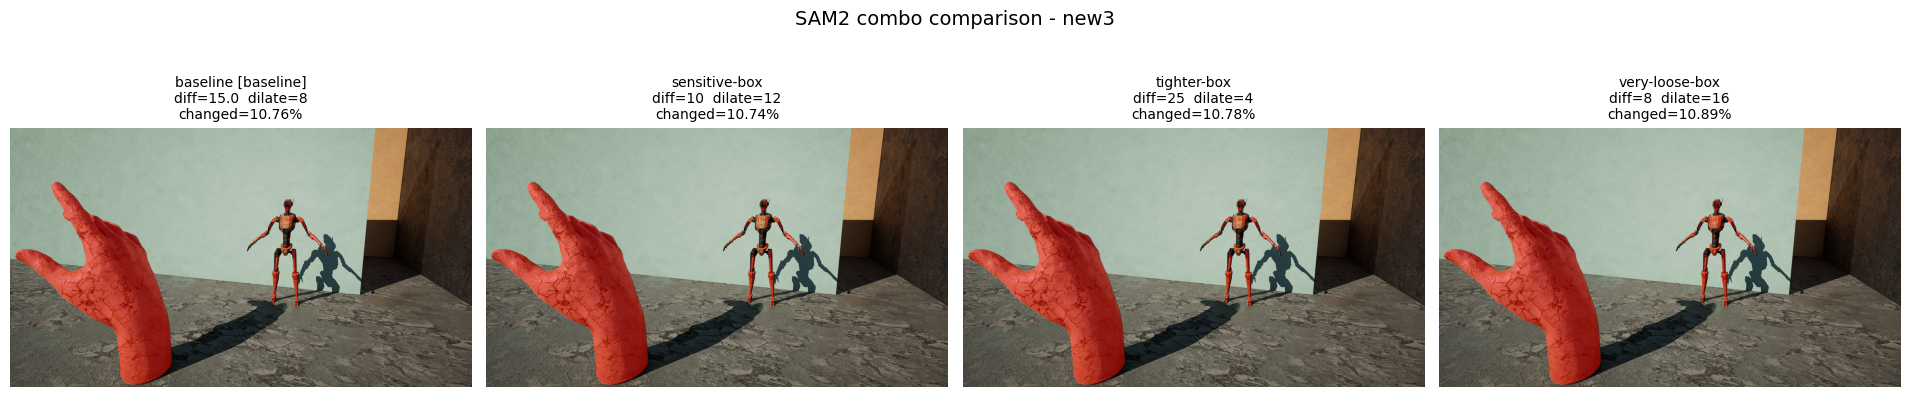

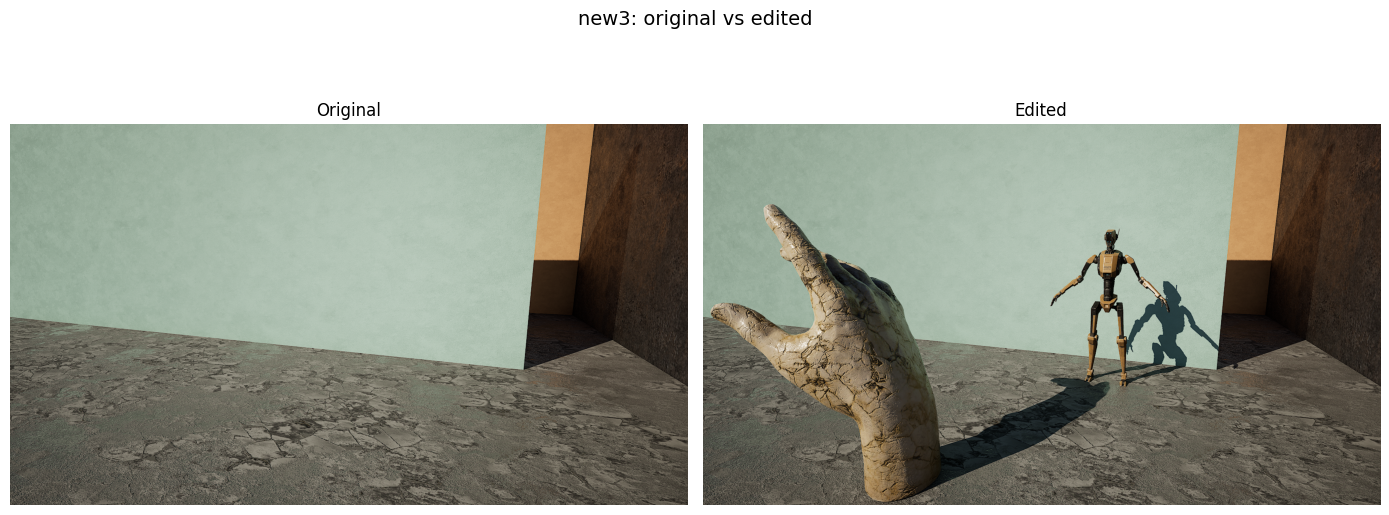

In [20]:
show_image_pair(original_img, edited_img, title=f'{DATASET}: original vs edited')


    ## Sweep 1 - `diff_thresh`

    Other params held at the SAM2 baseline from `params.py`.
    


  [SAM2] Diff bbox: [0, 159, 1278, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 160, 1181, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 160, 1181, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 160, 1181, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 161, 1181, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 161, 1180, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 161, 1180, 858]
  [SAM2] Loading model on cuda …


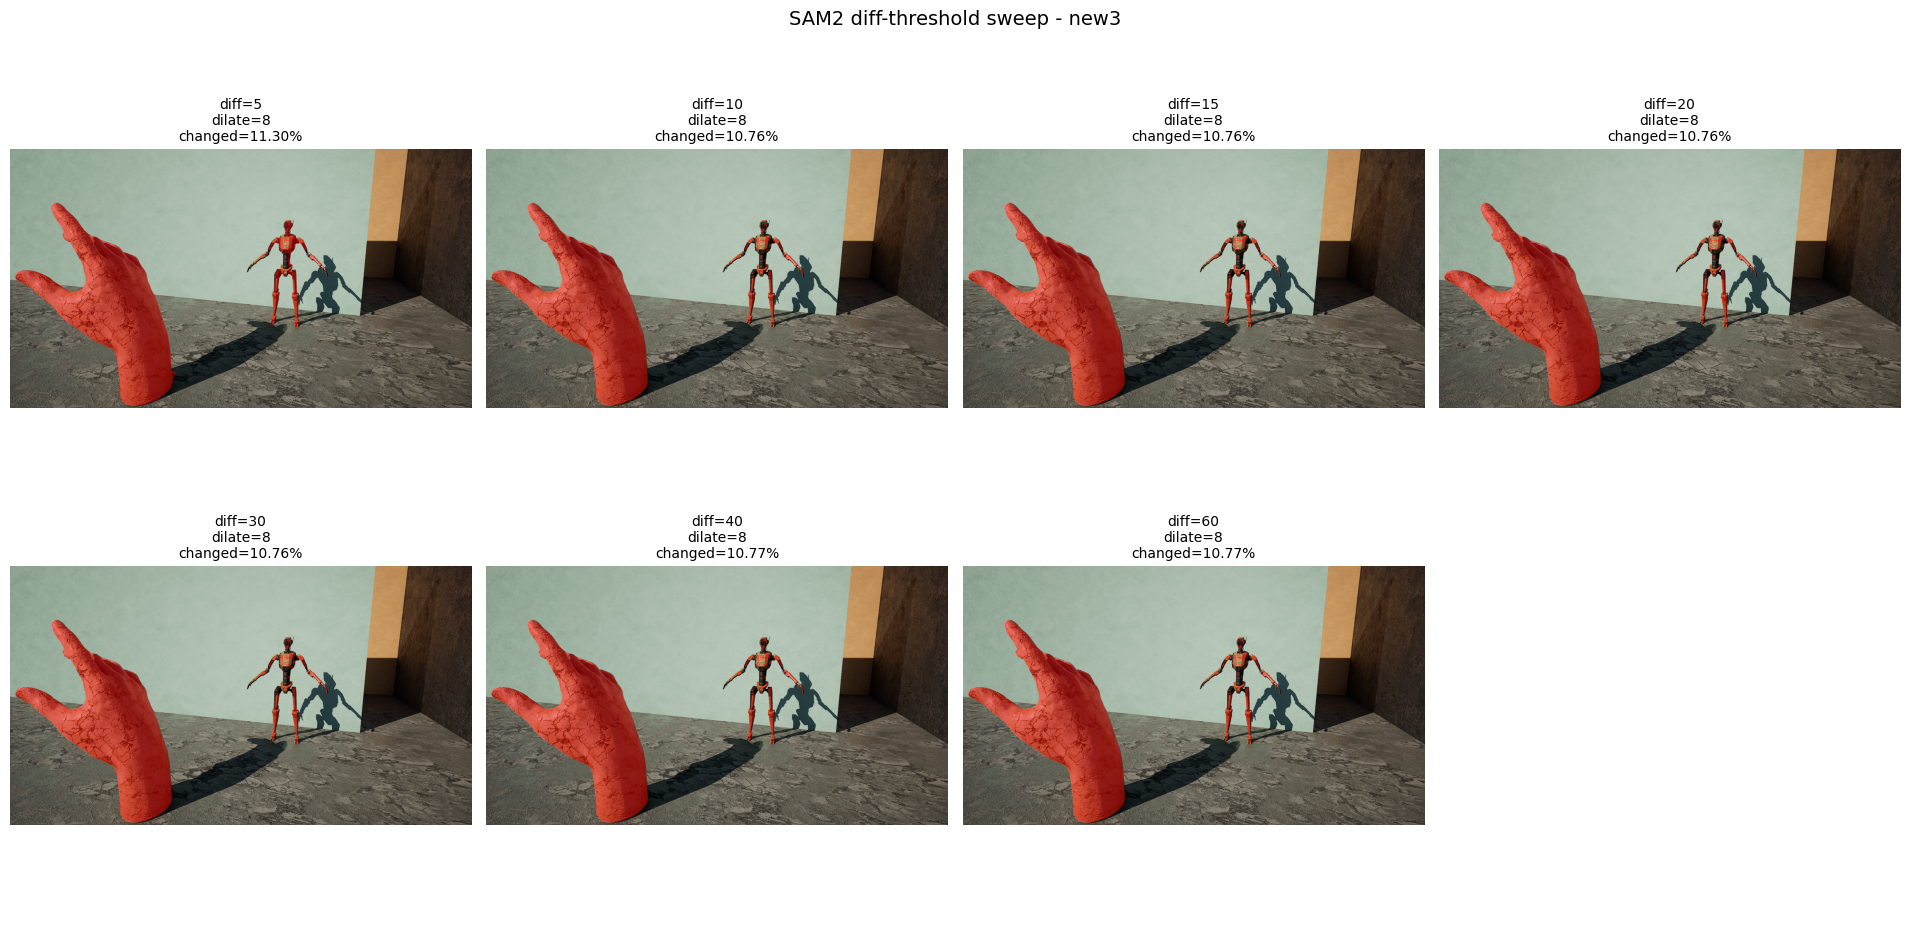

In [21]:
diff_thresh_values = [5, 10, 15, 20, 30, 40, 60]
diff_results = {}

for value in diff_thresh_values:
    mask, diff_map = sam2_mask(
        original_img, edited_img,
        checkpoint=str(checkpoint_path),
        model_cfg=SAM2_BASELINE['model_cfg'],
        diff_thresh=value,
        dilate=SAM2_BASELINE['dilate'],
    )
    diff_results[f'diff={value}'] = {
        'mask': mask,
        'diff_map': diff_map,
        'subtitle': f"dilate={SAM2_BASELINE['dilate']}",
    }

show_sweep(
    diff_results,
    edited_img,
    title=f'SAM2 diff-threshold sweep - {DATASET}',
    baseline_key=f"diff={SAM2_BASELINE['diff_thresh']}",
)


    ## Sweep 2 - `dilate`

    This controls how much the candidate diff region expands before the box prompt is built.
    


  [SAM2] Diff bbox: [4, 168, 1173, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [2, 166, 1175, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 164, 1177, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 160, 1181, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 156, 1185, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 152, 1256, 858]
  [SAM2] Loading model on cuda …


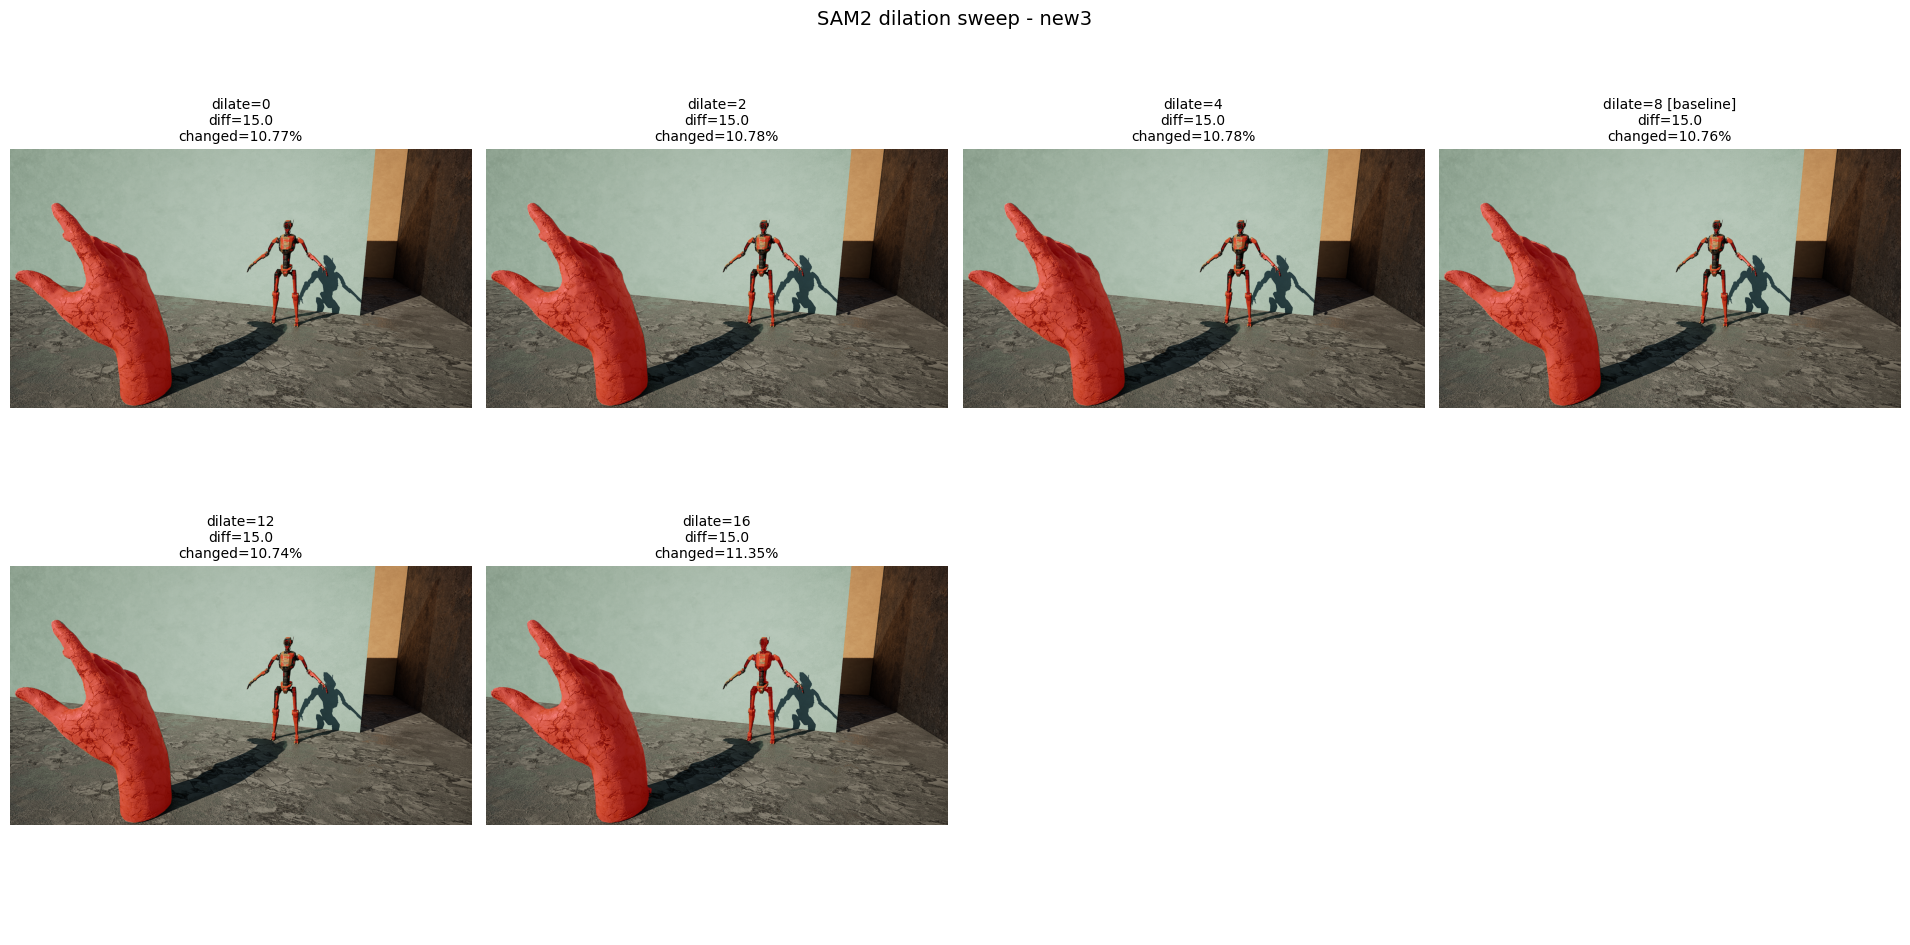

In [22]:
dilate_values = [0, 2, 4, 8, 12, 16]
dilate_results = {}

for value in dilate_values:
    mask, diff_map = sam2_mask(
        original_img, edited_img,
        checkpoint=str(checkpoint_path),
        model_cfg=SAM2_BASELINE['model_cfg'],
        diff_thresh=SAM2_BASELINE['diff_thresh'],
        dilate=value,
    )
    dilate_results[f'dilate={value}'] = {
        'mask': mask,
        'diff_map': diff_map,
        'subtitle': f"diff={SAM2_BASELINE['diff_thresh']}",
    }

show_sweep(
    dilate_results,
    edited_img,
    title=f'SAM2 dilation sweep - {DATASET}',
    baseline_key=f"dilate={SAM2_BASELINE['dilate']}",
)


    ## Combos

    Edit these combinations with the settings that gave the tightest useful box above.
    


  [SAM2] Diff bbox: [0, 160, 1181, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 156, 1185, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 164, 1177, 858]
  [SAM2] Loading model on cuda …
  [SAM2] Diff bbox: [0, 152, 1408, 858]
  [SAM2] Loading model on cuda …


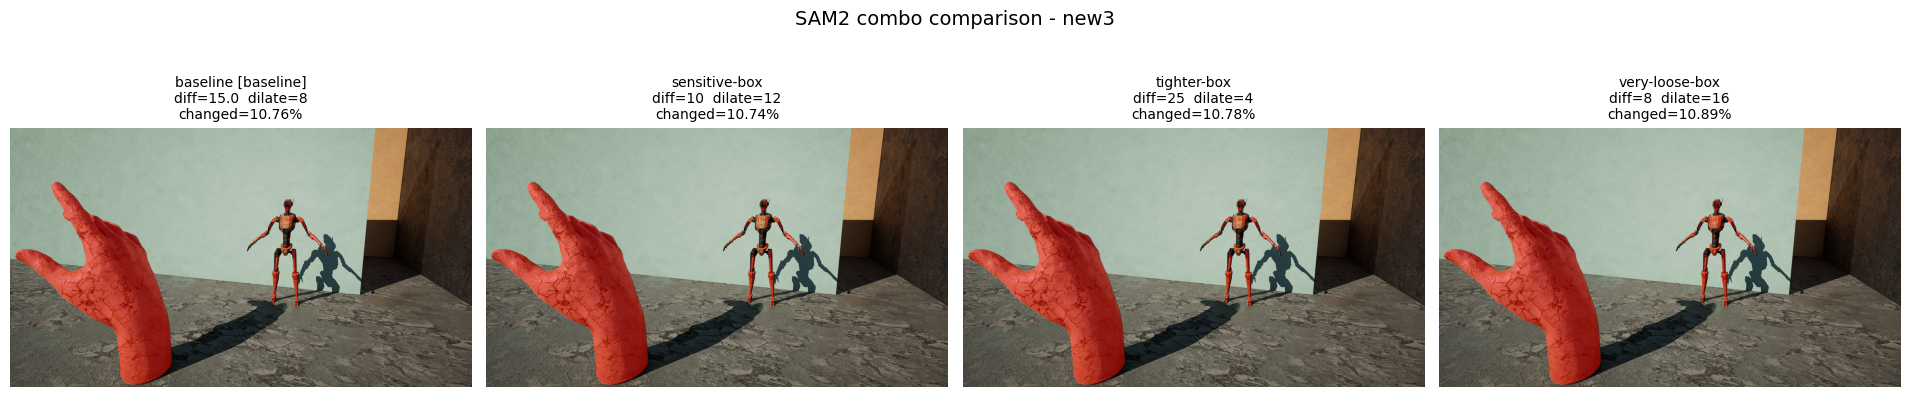

In [23]:
combo_configs = {
    'baseline': {**SAM2_BASELINE},
    'sensitive-box': {**SAM2_BASELINE, 'diff_thresh': 10, 'dilate': 12},
    'tighter-box': {**SAM2_BASELINE, 'diff_thresh': 25, 'dilate': 4},
    'very-loose-box': {**SAM2_BASELINE, 'diff_thresh': 8, 'dilate': 16},
}

combo_results = {}
for name, cfg in combo_configs.items():
    mask, diff_map = sam2_mask(
        original_img, edited_img,
        checkpoint=str(checkpoint_path),
        model_cfg=cfg['model_cfg'],
        diff_thresh=cfg['diff_thresh'],
        dilate=cfg['dilate'],
    )
    combo_results[name] = {
        'mask': mask,
        'diff_map': diff_map,
        'subtitle': f"diff={cfg['diff_thresh']}  dilate={cfg['dilate']}",
    }

show_sweep(combo_results, edited_img, title=f'SAM2 combo comparison - {DATASET}', baseline_key='baseline')

In [24]:
gc.collect()
if device == 'cuda':
    torch.cuda.empty_cache()
